# Task 2 - Age model - Google Colab

**Course:** DLBAIPEAI - Project Edge AI  
**Student:** W. Pretorius  
**Platform:** Google Colab

This notebook is the Google Colab version of the **Age model** for Task 2. It trains MobileNetV3-Small to classify a face as **Adult** or **Elderly**.

Adult means 20-59 years and Elderly means 60 years or older. Images below age 20 are excluded.

This Colab version keeps the same balanced training batches, class recall tracking, balanced-accuracy checkpoint selection and TensorFlow Lite checks as the desktop version.

Before running the notebook, choose **Runtime → Change runtime type → GPU** in Google Colab.

In [ ]:
# cell:folder
import os
import sys
from pathlib import Path
from datetime import datetime

PROJECT_DIR = Path("/content/project_edge_ai")
PROJECT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TASK = "age"
NOTEBOOK_NAME = "01_Age_Model_Colab"
NOTEBOOK_REVISION = "colab-age-balanced-v1"
GPU_READY = False

OUTPUT_DIR = (
    PROJECT_DIR
    / "results"
    / TASK
    / datetime.now().strftime("%Y%m%d_%H%M%S")
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Confirm that the runtime can save files before long processing starts.
probe = OUTPUT_DIR / ".write_check"
probe.write_text(
    "ok",
    encoding="utf-8",
)
probe.unlink()

os.environ["KERAS_HOME"] = str(
    PROJECT_DIR
    / "datasets"
    / "keras_cache"
)

os.environ["KAGGLEHUB_CACHE"] = str(
    PROJECT_DIR
    / "datasets"
    / "kagglehub_cache"
)

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("Python:", sys.version.split()[0])
print("Notebook revision:", NOTEBOOK_REVISION)
print("Project folder:", PROJECT_DIR)
print("Results folder:", OUTPUT_DIR)

## 2. Install the extra libraries

In this cell we install only the small helper libraries. TensorFlow and GPU support come from the Colab runtime.

In [ ]:
# cell:install
import subprocess
import sys
from importlib import metadata

# Colab already supplies TensorFlow and GPU support.
# Only the small helper libraries are installed here.
packages = {
    "kagglehub": "0.3.13",
    "tqdm": "4.67.1",
    "reportlab": "4.3.1",
    "nbformat": "5.10.4",
}

missing = []

for package, version in packages.items():
    try:
        installed = metadata.version(
            package
        )
    except metadata.PackageNotFoundError:
        installed = None

    if installed != version:
        missing.append(
            f"{package}=={version}"
        )

if missing:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--disable-pip-version-check",
            *missing,
        ]
    )

print("Colab helper libraries are ready.")
print("TensorFlow is provided by the Colab runtime.")

## 3. Keep the outputs for the PDF

In this cell we start recording later cell outputs for the final PDF. The code is kept here, not in a separate file. Setup-cell text is included, but its earlier output is not recorded.


In [ ]:
# cell:record
# This small tool stays inside the notebook. No helper file is needed.
import io
import re
import sys
import copy
import json

if "pdf_recorder" in globals():
    pdf_recorder.close()

class LiveNotebook:
    def __init__(self):
        self.ip = get_ipython()
        self.records = {}
        self.current = None
        self.stdout, self.stderr = sys.stdout, sys.stderr
        self.publish = self.ip.display_pub.publish
        self.format_data = self.ip.displayhook.write_format_data
        self.ip.display_pub.publish = self.capture_display
        self.ip.displayhook.write_format_data = self.capture_result
        self.ip.events.register("pre_run_cell", self.before)
        self.ip.events.register("post_run_cell", self.after)

    def before(self, info):
        self.restore()
        key = info.raw_cell.splitlines()[0].strip()
        self.current = key if key.startswith("# cell:") else None
        if self.current:
            self.records[self.current] = {
                "source": info.raw_cell,
                "execution_count": self.ip.execution_count,
                "outputs": [],
            }
            recorder = self
            class Tee:
                def __init__(self, original, name):
                    self.original, self.name = original, name
                def write(self, text):
                    outputs = recorder.records[recorder.current]["outputs"]
                    if outputs and outputs[-1].get("name") == self.name:
                        outputs[-1]["text"] += text
                    else:
                        outputs.append({"output_type": "stream", "name": self.name,
                                        "text": text})
                    return self.original.write(text)
                def flush(self):
                    return self.original.flush()
                def __getattr__(self, name):
                    return getattr(self.original, name)
            sys.stdout, sys.stderr = Tee(self.stdout, "stdout"), Tee(self.stderr, "stderr")

    def capture_display(self, data, metadata=None, **kwargs):
        if self.current:
            self.records[self.current]["outputs"].append({
                "output_type": "display_data", "data": copy.deepcopy(data),
                "metadata": metadata or {},
            })
        return self.publish(data=data, metadata=metadata, **kwargs)

    def capture_result(self, data, metadata=None):
        if self.current:
            self.records[self.current]["outputs"].append({
                "output_type": "execute_result", "data": copy.deepcopy(data),
                "metadata": metadata or {}, "execution_count": self.ip.execution_count,
            })
        return self.format_data(data, metadata)

    def restore(self):
        sys.stdout, sys.stderr = self.stdout, self.stderr

    def after(self, result):
        if self.current:
            error = result.error_before_exec or result.error_in_exec
            if error:
                self.records[self.current]["outputs"].append({
                    "output_type": "stream", "name": "stderr",
                    "text": f"{type(error).__name__}: {error}",
                })
        self.restore()
        self.current = None

    def close(self):
        self.restore()
        self.ip.display_pub.publish = self.publish
        self.ip.displayhook.write_format_data = self.format_data
        for event, function in [("pre_run_cell", self.before), ("post_run_cell", self.after)]:
            if function in self.ip.events.callbacks[event]:
                self.ip.events.unregister(event, function)

pdf_recorder = LiveNotebook()
print("Later cell outputs will be included in the PDF.")

## 4. Check that the Colab GPU can train

In this cell we check that Colab can see a GPU and run a real training calculation. We also enable mixed precision to make training faster.

In [5]:
# cell:imports
import time
import hashlib
import zipfile
import shutil
import platform
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import kagglehub
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from IPython.display import display, Markdown

get_ipython().run_line_magic(
    "matplotlib",
    "inline",
)

pd.set_option(
    "display.max_columns",
    12,
)

pd.set_option(
    "display.width",
    120,
)

print("TensorFlow:", tf.__version__)
print("System:", platform.platform())

gpus = tf.config.list_physical_devices(
    "GPU"
)

if not gpus:
    raise RuntimeError(
        "No GPU was found. In Colab choose Runtime → Change runtime type → GPU, "
        "then run the notebook again."
    )

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True,
        )
    except RuntimeError:
        pass

GPU_NAME = tf.config.experimental.get_device_details(
    gpus[0]
).get(
    "device_name",
    str(gpus[0]),
)

print("GPU found:", GPU_NAME)

# Check a real forward and backward calculation.
previous_placement = tf.config.get_soft_device_placement()
tf.config.set_soft_device_placement(
    False
)

try:
    with tf.device("/GPU:0"):
        probe_images = tf.random.normal(
            (2, 32, 32, 3)
        )

        probe_weights = tf.Variable(
            tf.random.normal(
                (3, 3, 3, 8)
            )
        )

        with tf.GradientTape() as tape:
            probe_output = tf.nn.conv2d(
                probe_images,
                probe_weights,
                strides=1,
                padding="SAME",
            )

            probe_loss = tf.reduce_mean(
                tf.square(
                    probe_output
                )
            )

        probe_gradient = tape.gradient(
            probe_loss,
            probe_weights,
        )

    if probe_gradient is None:
        raise RuntimeError(
            "The GPU did not calculate a gradient."
        )

    if "GPU" not in probe_output.device.upper():
        raise RuntimeError(
            "The test calculation did not run on the GPU."
        )

    if not np.isfinite(
        probe_gradient.numpy()
    ).all():
        raise RuntimeError(
            "The GPU gradient contains invalid values."
        )

finally:
    tf.config.set_soft_device_placement(
        previous_placement
    )

GPU_READY = True

# MobileNetV3 trains quickly with mixed precision on modern Colab GPUs.
tf.keras.mixed_precision.set_global_policy(
    "mixed_float16"
)

print(
    "Precision policy:",
    tf.keras.mixed_precision.global_policy().name,
)

print(
    "GPU forward and backward test: PASSED"
)

TensorFlow: 2.20.0
System: Linux-6.6.122+-x86_64-with-glibc2.39
GPU found: Tesla T4
Precision policy: mixed_float16
GPU forward and backward test: PASSED


## 5. Verify or download FairFace

In this cell we check the Colab Kaggle cache first. If FairFace is already present in this runtime, we verify and reuse it. Kaggle is only used when the dataset is missing.

In [6]:
# cell:dataset
KAGGLE_HANDLE = "mehmoodsheikh/fairface-dataset"
DATASETS_DIR = PROJECT_DIR / "datasets"
DATASETS_DIR.mkdir(parents=True, exist_ok=True)
LOCATION_FILE = DATASETS_DIR / "fairface_local_location.json"
# Only change this to True when you deliberately want to replace a damaged cache.
REPAIR_DATASET = False


def relative_image_name(value):
    value = str(value).strip().replace("\\", "/")
    parts = value.split("/")
    if not value or value.startswith("/") or ":" in value or ".." in parts:
        raise ValueError("Unsafe image path in the labels: " + value)
    return value


def fairface_layout(root):
    """Check labels and all image paths without any internet request."""
    root = Path(root).resolve()
    if not root.is_dir():
        raise FileNotFoundError(str(root))
    csvs, image_roots = [], [root, root / "images"]
    # Do not walk through every image just to find two CSV files.
    for current, dirs, names in os.walk(root):
        here = Path(current)
        csvs.extend(here / name for name in names if name.lower().endswith(".csv"))
        for directory in dirs:
            if directory.lower() == "train":
                image_roots.append(here)
        dirs[:] = [d for d in dirs if d.lower() not in {"train", "val", "images", "__macosx"}]
    selected = {}
    for split in ("train", "val"):
        exact = [p for p in csvs if p.name.lower() == f"fairface_label_{split}.csv"]
        candidates = exact or [p for p in csvs if split in p.stem.lower()]
        valid = []
        for path in candidates:
            try:
                frame = pd.read_csv(path)
            except (OSError, ValueError):
                continue
            if {"file", "age", "gender"}.issubset(frame.columns) and not frame.empty:
                if frame[["file", "age", "gender"]].isna().any().any():
                    raise ValueError(f"Missing labels in {path}")
                names = [relative_image_name(v) for v in frame["file"]]
                if len(set(names)) != len(names):
                    raise ValueError(f"Repeated file rows in {path}")
                valid.append((path, frame, names))
        if len(valid) != 1:
            raise ValueError(f"Expected one {split} label CSV in {root}; found {len(valid)}.")
        selected[split] = valid[0]
        image_roots.extend([valid[0][0].parent, valid[0][0].parent / "images"])
    # Also support a train/val pair under a folder called images.
    for base in list(image_roots):
        image_roots.append(base / "images")
    image_roots = list(dict.fromkeys(p.resolve() for p in image_roots if p.is_dir()))
    matched = []
    for image_root in image_roots:
        if all((image_root / selected[s][2][0]).is_file() for s in ("train", "val")):
            matched.append(image_root)
    if len(matched) != 1:
        raise ValueError(f"Could not find one matching image root in {root}.")
    image_root = matched[0]
    missing = []
    for split, (_, frame, names) in selected.items():
        for name in names:
            path = image_root / name
            try:
                if not path.is_file() or path.stat().st_size <= 0:
                    missing.append(str(path))
            except OSError:
                missing.append(str(path))
        if not missing:
            # This is a small readability check, not a claim that every image is perfect.
            for index in np.linspace(0, len(names)-1, min(4, len(names)), dtype=int):
                with Image.open(image_root / names[index]) as image:
                    image.verify()
    if missing:
        raise FileNotFoundError(f"{len(missing)} labelled images are missing/empty. Example: {missing[0]}")
    return {
        "root": root, "image_root": image_root,
        "train_csv": selected["train"][0], "val_csv": selected["val"][0],
        "train_count": len(selected["train"][1]), "val_count": len(selected["val"][1]),
    }


def get_local_fairface():
    candidates = []
    if LOCATION_FILE.is_file():
        try:
            candidates.append(Path(json.loads(LOCATION_FILE.read_text(encoding="utf-8"))["root"]))
        except (OSError, ValueError, KeyError):
            pass
    caches = [
        Path(os.environ.get("KAGGLEHUB_CACHE", str(DATASETS_DIR / "kagglehub_cache"))),
        DATASETS_DIR / "kagglehub_cache", DATASETS_DIR / "kagglehub" / "_cache",
        DATASETS_DIR / "kagglehub", Path.home() / ".cache" / "kagglehub",
    ]
    for cache in dict.fromkeys(caches):
        versions = cache / "datasets" / "mehmoodsheikh" / "fairface-dataset" / "versions"
        if versions.is_dir():
            candidates.extend(sorted(
                (p for p in versions.iterdir() if p.is_dir()),
                key=lambda p: int(p.name) if p.name.isdigit() else -1, reverse=True))
    # Reuse a previous extracted FairFace copy too. No images are deleted or moved.
    candidates.extend([DATASETS_DIR / "fairface", DATASETS_DIR / "fairface-dataset"])
    issues = []
    for candidate in dict.fromkeys(p.resolve() for p in candidates if p.is_dir()):
        if not any(candidate.iterdir()):
            continue
        try:
            return fairface_layout(candidate), issues
        except (OSError, ValueError) as error:
            issues.append(f"{candidate}: {error}")
    return None, issues


layout, local_issues = get_local_fairface()
if layout is not None and not REPAIR_DATASET:
    print("Verified local FairFace. Kaggle is not called; nothing is downloaded.")
else:
    if local_issues and not REPAIR_DATASET:
        print("\n".join(local_issues))
        raise RuntimeError(
            "Local FairFace files exist but verification failed. No download was started. "
            "Correct the path/files, or set REPAIR_DATASET=True to request a fresh Kaggle copy.")
    import kagglehub
    print("Downloading FairFace from Kaggle..." if not REPAIR_DATASET else "Repair download requested...")
    downloaded = Path(kagglehub.dataset_download(KAGGLE_HANDLE, force_download=REPAIR_DATASET))
    layout = fairface_layout(downloaded)
    print("Downloaded files verified.")

DATA_DIR = layout["root"]
IMAGE_ROOT = layout["image_root"]
TRAIN_CSV, VAL_CSV = layout["train_csv"], layout["val_csv"]
LOCATION_FILE.write_text(json.dumps({k: str(v) if isinstance(v, Path) else v
                                   for k, v in layout.items()}, indent=2), encoding="utf-8")
print("Dataset folder:", DATA_DIR)
print("Image root:", IMAGE_ROOT)
print("Labelled images:", {"train": layout["train_count"], "val": layout["val_count"]})

100%|██████████| 550M/550M [00:07<00:00, 79.7MB/s]


Extracting files...
Downloaded files verified.
Dataset folder: /content/project_edge_ai/datasets/kagglehub_cache/datasets/mehmoodsheikh/fairface-dataset/versions/1
Image root: /content/project_edge_ai/datasets/kagglehub_cache/datasets/mehmoodsheikh/fairface-dataset/versions/1/FairFace
Labelled images: {'train': 86744, 'val': 10954}


## 6. Read the image labels

In this cell we read the FairFace train and validation labels from the Kaggle dataset. The original validation data is kept as the final holdout test.

In [7]:
# cell:labels
parts = []

for csv_path, split in [
    (TRAIN_CSV, "development"),
    (VAL_CSV, "holdout"),
]:
    frame = pd.read_csv(csv_path)

    required = {"file", "age", "gender"}

    if not required.issubset(frame.columns):
        raise ValueError(
            f"Unexpected FairFace columns in {csv_path.name}."
        )

    relative_paths = (
        frame["file"]
        .astype(str)
        .str.replace("\\", "/", regex=False)
    )

    resolved_paths = [
        (IMAGE_ROOT / value).resolve()
        for value in relative_paths
    ]

    missing = [
        path for path in resolved_paths
        if not path.is_file()
    ]

    if missing:
        raise FileNotFoundError(
            f"{len(missing)} labelled FairFace images are missing. "
            f"Example: {missing[0]}"
        )

    frame["path"] = [
        str(path)
        for path in resolved_paths
    ]

    frame["source_split"] = split

    frame[
        ["face_x", "face_y", "face_width", "face_height"]
    ] = -1

    parts.append(frame)


raw = pd.concat(
    parts,
    ignore_index=True,
)

print("Actual FairFace labels loaded:", len(raw))

print("\nOriginal source split counts:")
display(
    raw["source_split"]
    .value_counts()
    .rename("images")
    .to_frame()
)

display(raw.head())

Actual FairFace labels loaded: 97698

Original source split counts:


,images
source_split,
development,86744
holdout,10954


,file,age,gender,race,service_test,path,source_split,face_x,face_y,face_width,face_height
0,train/1.jpg,50-59,Male,East Asian,True,/content/project_edge_ai/datasets/kagglehub_ca...,development,-1,-1,-1,-1
1,train/2.jpg,30-39,Female,Indian,False,/content/project_edge_ai/datasets/kagglehub_ca...,development,-1,-1,-1,-1
2,train/3.jpg,3-9,Female,Black,False,/content/project_edge_ai/datasets/kagglehub_ca...,development,-1,-1,-1,-1
3,train/4.jpg,20-29,Female,Indian,True,/content/project_edge_ai/datasets/kagglehub_ca...,development,-1,-1,-1,-1
4,train/5.jpg,20-29,Female,Indian,True,/content/project_edge_ai/datasets/kagglehub_ca...,development,-1,-1,-1,-1


## 7. Choose the training settings

In this cell we choose the model settings and create the two age classes. Adult is 20-59 years and Elderly is 60 years or older. Images below age 20 are removed.

In [8]:
# cell:settings
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
HEAD_EPOCHS = 8
FINE_TUNE_EPOCHS = 20

CLASS_NAMES = ["Adult", "Elderly"]
N_CLASSES = len(CLASS_NAMES)
TARGET_COLUMN = "age"

# FairFace gives age ranges instead of exact ages.
# We use only ranges that fit clearly into our two project classes.
AGE_TO_CLASS = {
    "20-29": 0,
    "30-39": 0,
    "40-49": 0,
    "50-59": 0,
    "60-69": 1,
    "more than 70": 1,
}

# Set this to True only for a quick pipeline test.
# Keep it False for the final model and report.
FAST_MODE = False

if FAST_MODE:
    HEAD_EPOCHS = 2
    FINE_TUNE_EPOCHS = 3
    print(
        "FAST_MODE is ON. This is a quick pipeline test, not the final experiment."
    )
else:
    print(
        "FAST_MODE is OFF. Full training settings are active."
    )

tf.keras.utils.set_random_seed(SEED)

original_count = len(raw)

# Keep only the age ranges used by this project.
raw = raw.loc[raw["age"].isin(AGE_TO_CLASS)].copy()
raw["label"] = raw["age"].map(AGE_TO_CLASS).astype(int)

excluded_count = original_count - len(raw)

if raw.empty:
    raise ValueError("No Adult or Elderly FairFace images were found.")

if set(raw["label"].unique()) != {0, 1}:
    raise ValueError("Both Adult and Elderly classes must be present.")

print("Class order:", dict(enumerate(CLASS_NAMES)))
print("Images kept:", len(raw))
print("Images below age 20 excluded:", excluded_count)

print("\nOriginal FairFace age ranges kept:")
display(
    pd.crosstab(
        raw["age"],
        raw["label"].map(dict(enumerate(CLASS_NAMES))),
    )
)
# Set these checks before training, not after looking at holdout results.
MOBILE_IMAGES_PER_CLASS = 256
FP32_LIMITS = {
    "max_abs": 0.01, "mean_abs": 0.001, "min_agreement": 0.99,
    "max_balanced_accuracy_drop": 0.01, "max_class_recall_drop": 0.02,
}
INT8_LIMITS = {
    "max_abs": 0.15, "mean_abs": 0.02, "min_agreement": 0.97,
    "max_balanced_accuracy_drop": 0.02, "max_class_recall_drop": 0.03,
}
if BATCH_SIZE < 2 or BATCH_SIZE % 2:
    raise ValueError("Use an even batch size so each class gets half the batch.")

FAST_MODE is OFF. Full training settings are active.
Class order: {0: 'Adult', 1: 'Elderly'}
Images kept: 73659
Images below age 20 excluded: 24039

Original FairFace age ranges kept:


label,Adult,Elderly
age,,
20-29,28898,0
30-39,21580,0
40-49,12097,0
50-59,7024,0
60-69,0,3100
more than 70,0,960


## 8. Check the images

In this cell we open each image and check its face crop. We record bad files instead of hiding them. The check can take a few minutes.


In [9]:
# cell:audit
BOX_COLUMNS = ["face_x", "face_y", "face_width", "face_height"]

def open_face(path, box):
    with Image.open(path) as original:
        original.load()
        image = original.convert("RGB")
    x, y, width, height = map(float, box)
    if not (x == y == width == height == -1):
        if not np.isfinite([x, y, width, height]).all() or width <= 0 or height <= 0:
            raise ValueError("Invalid face box.")
        bounds = (max(0, int(x)), max(0, int(y)),
                  min(image.width, int(x + width)), min(image.height, int(y + height)))
        if bounds[2] <= bounds[0] or bounds[3] <= bounds[1]:
            raise ValueError("Face box is outside the image.")
        image = image.crop(bounds)
    if min(image.size) < 16:
        raise ValueError("Face crop is smaller than 16 pixels.")
    return image

def check_image(row):
    try:
        image = open_face(row["path"], [row[column] for column in BOX_COLUMNS])
        digest = hashlib.sha256(str(image.size).encode() + image.tobytes()).hexdigest()
        return {"sha256": digest, "image_error": ""}
    except Exception as error:
        return {"sha256": "", "image_error": str(error)}

with ThreadPoolExecutor(max_workers=min(8, os.cpu_count() or 1)) as pool:
    checks = list(tqdm(pool.map(check_image, raw.to_dict("records")),
                       total=len(raw), desc="Checking face images"))
checked = pd.concat([raw.reset_index(drop=True), pd.DataFrame(checks)], axis=1)

# The image check can take several minutes. Make sure the results folder
# still exists before we save the file.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_check_file = OUTPUT_DIR / "image_checks.csv"
checked.to_csv(image_check_file, index=False)

print("Image check saved to:", image_check_file)
print("Unreadable or invalid images:", int(checked["image_error"].ne("").sum()))
clean_data = checked.loc[checked["image_error"].eq("")].copy()
if clean_data.empty:
    raise ValueError("No usable face images were found.")

Checking face images: 100%|██████████| 73659/73659 [01:01<00:00, 1192.51it/s]


Image check saved to: /content/project_edge_ai/results/age/20260915_044643/image_checks.csv
Unreadable or invalid images: 0


## 9. Remove exact repeats

In this cell we remove exact duplicate face images and conflicting labels. A holdout copy is kept instead of a training copy. Different photos of the same person may still remain.


In [10]:
# cell:duplicates
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
label_columns = ['age', 'gender']
conflicts = clean_data.groupby("sha256")[label_columns].nunique().max(axis=1)
conflict_hashes = set(conflicts[conflicts > 1].index)
conflicting = clean_data["sha256"].isin(conflict_hashes)
print("Images with conflicting labels:", int(conflicting.sum()))
clean_data = clean_data.loc[~conflicting].copy()
clean_data["priority"] = clean_data["source_split"].map({"holdout": 0, "development": 1})
clean_data = clean_data.sort_values(["priority", "path"])
repeats = clean_data.duplicated("sha256", keep="first")
clean_data.loc[repeats].to_csv(OUTPUT_DIR / "duplicate_images.csv", index=False)
print("Exact repeated images removed:", int(repeats.sum()))
clean_data = clean_data.loc[~repeats].copy()

Images with conflicting labels: 65
Exact repeated images removed: 45


## 10. Keep the same training, validation and holdout splits

In this cell we use the same 15% validation rule and random seed as before. The original FairFace validation split remains the holdout. Age-range and gender groups guide the split. We do not repeat or augment validation and holdout images. The holdout has already been inspected in earlier runs.

In [11]:
# cell:split
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
development = clean_data.loc[clean_data["source_split"].eq("development")].copy()
test_df = clean_data.loc[clean_data["source_split"].eq("holdout")].copy()
strata = (
    development["age"].astype(str)
    + "_"
    + development["gender"].astype(str)
)
if strata.value_counts().min() < 2:
    raise ValueError("A group has fewer than two images. Review the data before splitting.")
train_df, val_df = train_test_split(development, test_size=0.15, random_state=SEED,
                                   stratify=strata)
frames = {"train": train_df, "validation": val_df, "holdout": test_df}
for name, frame in frames.items():
    if set(frame["label"]) != set(range(N_CLASSES)):
        raise ValueError(f"The {name} set does not contain every required class.")
    frame.to_csv(OUTPUT_DIR / f"{name}_images.csv", index=False)
for first, second in [(train_df, val_df), (train_df, test_df), (val_df, test_df)]:
    assert set(first["sha256"]).isdisjoint(set(second["sha256"]))
print({name: len(frame) for name, frame in frames.items()})

# Optional smaller sets for a quick Colab pipeline test.
# The final model must use FAST_MODE=False.
if FAST_MODE:
    def quick_subset(frame, per_class):
        parts = []

        for label, group in frame.groupby(
            "label"
        ):
            parts.append(
                group.sample(
                    min(
                        per_class,
                        len(group),
                    ),
                    random_state=(
                        SEED
                        + int(label)
                    ),
                )
            )

        return pd.concat(
            parts,
            ignore_index=True,
        )

    train_df = quick_subset(
        train_df,
        1200,
    )

    val_df = quick_subset(
        val_df,
        300,
    )

    test_df = quick_subset(
        test_df,
        300,
    )

    frames = {
        "train": train_df,
        "validation": val_df,
        "holdout": test_df,
    }

    print(
        "FAST_MODE subset sizes:",
        {
            name: len(frame)
            for name, frame in frames.items()
        },
    )

{'train': 55533, 'validation': 9801, 'holdout': 8215}


## 11. Count each class

In this cell we count Adult and Elderly images in the training, validation and holdout sets. This shows whether one class has more examples than the other.

,train,validation,holdout
Adult,52463,9259,7776
Elderly,3070,542,439


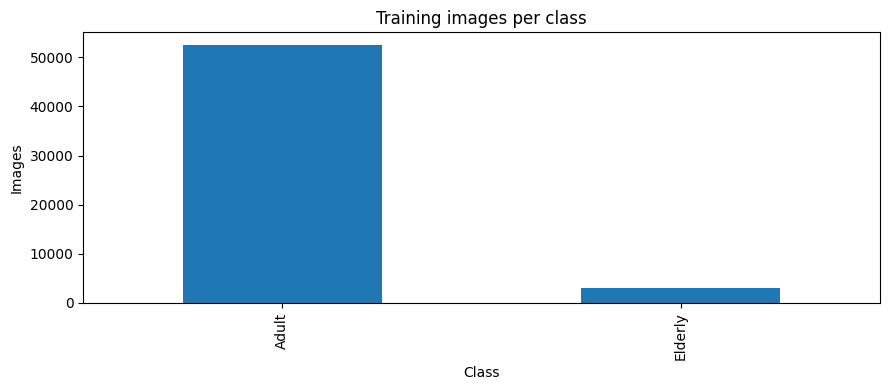

In [12]:
# cell:counts
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
counts = pd.DataFrame({name: frame["label"].value_counts().reindex(range(N_CLASSES), fill_value=0)
                       for name, frame in frames.items()})
counts.index = CLASS_NAMES
display(counts)
counts.to_csv(OUTPUT_DIR / "class_counts.csv")
fig, ax = plt.subplots(figsize=(9, 4))
counts["train"].plot.bar(ax=ax)
ax.set(title="Training images per class", xlabel="Class", ylabel="Images")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "class_counts.png", dpi=150)
plt.show()

## 12. Look at a few training images

In this cell we inspect a few face crops and labels. Keep these research images private. Set SHOW_FACE_IMAGES to False before making a copy that must not contain dataset photos.


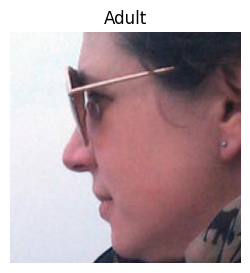

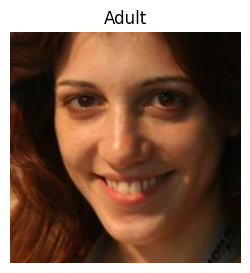

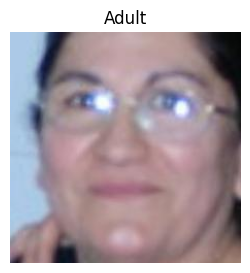

In [13]:
# cell:samples
SHOW_FACE_IMAGES = True
if SHOW_FACE_IMAGES:
    for _, row in train_df.sample(3, random_state=SEED).iterrows():
        face = open_face(row["path"], row[BOX_COLUMNS])
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.imshow(face)
        ax.set_title(CLASS_NAMES[int(row["label"])])
        ax.axis("off")
        plt.show()

## 13. Prepare the model input

In this cell we load RGB face crops in small batches. Pixels stay between 0 and 255 because the model includes input scaling. Validation and holdout keep their existing images and order.

In [14]:
# cell:input
def load_pixels(path, box):
    path = path.item() if isinstance(path, np.ndarray) else path
    path = path.decode("utf-8") if isinstance(path, bytes) else str(path)
    image = open_face(path, box).resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)
    return np.asarray(image, dtype=np.float32)


def read_image(path, box, label):
    image = tf.numpy_function(load_pixels, [path, box], tf.float32)
    image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))
    return image, label


def make_dataset(frame):
    if frame.empty:
        raise ValueError("Cannot make an empty image dataset.")
    dataset = tf.data.Dataset.from_tensor_slices((
        frame["path"].astype(str).to_numpy(),
        frame[BOX_COLUMNS].to_numpy(dtype=np.float32),
        frame["label"].to_numpy(dtype=np.int32),
    ))
    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = dataset.with_options(options)
    dataset = dataset.map(read_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)
images, labels = next(iter(val_ds))
print("Input shape:", images.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Input shape: (32, 224, 224, 3)
Pixel range: 0.0 to 255.0


## 14. Make small changes to training images

In this cell we make small random changes to the training images. We use horizontal flips, brightness and contrast changes. The function is compiled once so it does not create the same TensorFlow warnings for every batch.

In [15]:
# cell:augmentation
# This function is compiled once and then reused for every batch.
# It avoids the repeated Keras Random* conversion warnings.

@tf.function(
    input_signature=[
        tf.TensorSpec(
            shape=[None, IMAGE_SIZE, IMAGE_SIZE, 3],
            dtype=tf.float32,
        )
    ],
    reduce_retracing=True,
)
def augment_batch(images):
    images = tf.image.random_flip_left_right(
        images,
        seed=SEED,
    )
    images = tf.image.random_brightness(
        images,
        max_delta=10.0,
        seed=SEED + 1,
    )
    images = tf.image.random_contrast(
        images,
        lower=0.90,
        upper=1.10,
        seed=SEED + 2,
    )
    return tf.clip_by_value(images, 0.0, 255.0)


print(
    "Training augmentation ready: horizontal flip, "
    "brightness and contrast."
)
print(
    "The augmentation is compiled once, so repeated "
    "Random* conversion warnings should not appear."
)

Training augmentation ready: horizontal flip, brightness and contrast.
The augmentation is compiled once, so repeated Random* conversion warnings should not appear.


## 15. Make balanced training batches

In this cell each batch gets **16 Adult and 16 Elderly faces** when the batch size is 32. All original training images stay available. Elderly images are seen more often with new small changes. We do not add new people or copy images into the other splits. Class weights are turned off so we do not correct the imbalance twice.

In [16]:
# cell:weights
def balanced_epoch_indices(labels, batch_size, seed):
    """Make exact half/half batches; visit each class in shuffled cycles."""
    labels = np.asarray(labels, dtype=np.int32)
    if batch_size < 2 or batch_size % 2:
        raise ValueError("Batch size must be positive and even.")
    if set(np.unique(labels)) != {0, 1}:
        raise ValueError("Both age classes must be present.")
    half = batch_size // 2
    members = [np.flatnonzero(labels == class_id) for class_id in (0, 1)]
    steps = int(np.ceil(max(map(len, members)) / half))
    needed = steps * half
    rng = np.random.default_rng(seed)
    selections = []
    for indices in members:
        cycles = [rng.permutation(indices) for _ in range(int(np.ceil(needed / len(indices))))]
        selections.append(np.concatenate(cycles)[:needed].reshape(steps, half))
    batches = np.concatenate(selections, axis=1)
    for row in batches:
        rng.shuffle(row)
    return batches


class BalancedAgeBatches(tf.keras.utils.Sequence):
    def __init__(self, frame, batch_size, seed, use_augmentation=True):
        self.frame = frame.reset_index(drop=True).copy()
        self.batch_size, self.seed = batch_size, seed
        self.use_augmentation = bool(use_augmentation)
        self.epoch = 0
        self.labels = self.frame["label"].to_numpy(dtype=np.int32)
        self.paths = self.frame["path"].astype(str).to_numpy()
        self.boxes = self.frame[BOX_COLUMNS].to_numpy(dtype=np.float32)
        self.indices = balanced_epoch_indices(self.labels, batch_size, seed)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        positions = self.indices[index]
        images = np.stack(
            [
                load_pixels(self.paths[i], self.boxes[i])
                for i in positions
            ]
        ).astype(np.float32)

        if self.use_augmentation:
            images = augment_batch(
                tf.convert_to_tensor(
                    images,
                    dtype=tf.float32,
                )
            ).numpy()

        return images, self.labels[positions]

    def on_epoch_end(self):
        self.epoch += 1
        self.indices = balanced_epoch_indices(self.labels, self.batch_size, self.seed+self.epoch)


train_ds = BalancedAgeBatches(train_df, BATCH_SIZE, SEED, use_augmentation=True)
CLASS_WEIGHTS = None
STEPS_PER_EPOCH = len(train_ds)
# Check all planned batches, not just one example.
planned_labels = train_ds.labels[train_ds.indices]
assert np.all(np.sum(planned_labels == 0, axis=1) == BATCH_SIZE//2)
assert np.all(np.sum(planned_labels == 1, axis=1) == BATCH_SIZE//2)
assert set(train_ds.indices.ravel()) == set(range(len(train_df)))
exposure = pd.DataFrame({
    "class": CLASS_NAMES,
    "unique_training_images": [int((train_ds.labels == i).sum()) for i in (0, 1)],
    "samples_per_epoch": [STEPS_PER_EPOCH*(BATCH_SIZE//2)]*2,
})
exposure["average_uses_per_epoch"] = exposure["samples_per_epoch"] / exposure["unique_training_images"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
exposure.to_csv(OUTPUT_DIR / "balanced_training_exposure.csv", index=False)
display(exposure)
print("Every batch:", BATCH_SIZE//2, "Adult +", BATCH_SIZE//2, "Elderly")
print("Batches per epoch:", STEPS_PER_EPOCH)
print("Class weights: off. Validation and holdout counts are unchanged.")

,class,unique_training_images,samples_per_epoch,average_uses_per_epoch
0,Adult,52463,52464,1.000019
1,Elderly,3070,52464,17.089251


Every batch: 16 Adult + 16 Elderly
Batches per epoch: 3279
Class weights: off. Validation and holdout counts are unchanged.


## 16. Build the model

In this cell we build MobileNetV3Small with ImageNet weights. We add a new output layer with two choices, Adult and Elderly. The feature layers stay frozen at first.

In [17]:
# cell:model
if not globals().get(
    "GPU_READY",
    False,
):
    raise RuntimeError(
        "Pass the GPU test before building the model."
    )


def build_age_model(
    weights="imagenet",
):
    backbone = tf.keras.applications.MobileNetV3Small(
        input_shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3,
        ),
        include_top=False,
        weights=weights,
        include_preprocessing=True,
    )

    backbone.trainable = False

    inputs = tf.keras.Input(
        shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3,
        ),
        name="face_rgb",
    )

    features = backbone(
        inputs,
        training=False,
    )

    features = tf.keras.layers.GlobalAveragePooling2D()(
        features
    )

    features = tf.keras.layers.Dropout(
        0.30
    )(
        features
    )

    # Keep final scores in float32 even when the backbone uses mixed precision.
    outputs = tf.keras.layers.Dense(
        N_CLASSES,
        activation="softmax",
        dtype="float32",
        name="class_scores",
    )(
        features
    )

    network = tf.keras.Model(
        inputs,
        outputs,
        name=TASK + "_model",
    )

    return network, backbone.name


with tf.device("/GPU:0"):
    model, BACKBONE_NAME = build_age_model(
        weights="imagenet"
    )

model.summary()

print(
    "Number of model parameters:",
    model.count_params(),
)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "age_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ face_rgb (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_scores (Dense)            │ (None, 2)              │         1,154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 940,274 (3.59 MB)

 Trainable params: 1,154 (4.51 KB)

 Non-trainable params: 939,120 (3.58 MB)

Number of model parameters: 940274


## 17. Track recall and save the best checkpoint

In this cell we track recall for Adult and Elderly during both training and validation. Recall means the fraction of that class found correctly. Balanced accuracy is the average of the two recalls. The best checkpoint is chosen by **validation balanced accuracy**, not overall accuracy.

In [18]:
# cell:training_setup
@tf.keras.utils.register_keras_serializable(package="EdgeAI")
class AgeRecall(tf.keras.metrics.Metric):
    def __init__(self, class_id=None, name="balanced_accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        if class_id not in (None, 0, 1):
            raise ValueError("class_id must be 0, 1 or None.")
        self.class_id = class_id
        self.cm = self.add_weight(name="counts", shape=(2, 2), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        prediction = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = None
        if sample_weight is not None:
            weights = tf.broadcast_to(tf.reshape(tf.cast(sample_weight, self.dtype), [-1]), tf.shape(truth))
        counts = tf.math.confusion_matrix(truth, prediction, num_classes=2,
                                         weights=weights, dtype=self.dtype)
        self.cm.assign_add(counts)

    def result(self):
        recalls = tf.math.divide_no_nan(tf.linalg.diag_part(self.cm), tf.reduce_sum(self.cm, axis=1))
        return tf.reduce_mean(recalls) if self.class_id is None else recalls[self.class_id]

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

    def get_config(self):
        return dict(super().get_config(), class_id=self.class_id)


def compile_model(network, learning_rate):
    network.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=1e-4,
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy", AgeRecall(0, name="recall_adult"),
                 AgeRecall(1, name="recall_elderly"), AgeRecall(name="balanced_accuracy")],
        jit_compile=False,
    )


class PrintAgeRecall(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        values = logs or {}
        print(
            f"Validation - Adult recall: {values.get('val_recall_adult', float('nan')):.2%} | "
            f"Elderly recall: {values.get('val_recall_elderly', float('nan')):.2%} | "
            f"Balanced accuracy: {values.get('val_balanced_accuracy', float('nan')):.2%}",
            flush=True,
        )


def callbacks(stage):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            str(OUTPUT_DIR / f"best_{stage}.weights.h5"), monitor="val_balanced_accuracy",
            mode="max", save_best_only=True, save_weights_only=True),
        tf.keras.callbacks.EarlyStopping(monitor="val_balanced_accuracy", mode="max",
                                         patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_balanced_accuracy", mode="max",
                                            patience=2, factor=0.5, min_lr=1e-7),
        tf.keras.callbacks.CSVLogger(str(OUTPUT_DIR / f"{stage}_training.csv")),
        PrintAgeRecall(), tf.keras.callbacks.TerminateOnNaN(),
    ]

compile_model(model, 1e-3)
print("Each epoch reports train and validation recall for both classes.")
print("Checkpoint files save model weights only; optimizer-state HDF5 warnings are avoided.")

Each epoch reports train and validation recall for both classes.
Checkpoint files save model weights only; optimizer-state HDF5 warnings are avoided.


## 18. Train the new output layer

In this cell we train the model's new output layer. The pretrained image-feature layers do not change yet.


In [19]:
# cell:train_head
if not globals().get("GPU_READY", False):
    raise RuntimeError("The GPU test must pass before training.")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

started = time.perf_counter()

head_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks("head"),
    verbose=2,
)

head_seconds = time.perf_counter() - started

print(
    "Training time, minutes:",
    round(head_seconds / 60, 2),
)

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
Validation - Adult recall: 81.76% | Elderly recall: 80.81% | Balanced accuracy: 81.29%
3279/3279 - 264s - 80ms/step - accuracy: 0.7774 - balanced_accuracy: 0.7774 - loss: 0.4735 - recall_adult: 0.7836 - recall_elderly: 0.7712 - val_accuracy: 0.8171 - val_balanced_accuracy: 0.8129 - val_loss: 0.4294 - val_recall_adult: 0.8176 - val_recall_elderly: 0.8081 - learning_rate: 0.0010
Epoch 2/8
Validation - Adult recall: 83.05% | Elderly recall: 78.60% | Balanced accuracy: 80.83%
3279/3279 - 225s - 69ms/step - accuracy: 0.7869 - balanced_accuracy: 0.7869 - loss: 0.4580 - recall_adult: 0.7934 - recall_elderly: 0.7803 - val_accuracy: 0.8281 - val_balanced_accuracy: 0.8083 - val_loss: 0.4071 - val_recall_adult: 0.8305 - val_recall_elderly: 0.7860 - learning_rate: 0.0010
Epoch 3/8
Validation - Adult recall: 82.57% | Elderly recall: 78.97% | Balanced accuracy: 80.77%
3279/3279 - 279s - 85ms/step - accuracy: 0.7855 - balanced_accuracy: 0.7855 - loss: 0.4602 - recall_adult: 0.7934 - recall_

## 19. Prepare fine-tuning

In this cell we load the best first-stage model. We allow the last third of the feature layers to learn. Batch-normalisation layers stay frozen.


In [20]:
# cell:unfreeze
def set_feature_stage(stage):
    features = model.get_layer(BACKBONE_NAME)
    if stage == "head":
        features.trainable = False
    elif stage == "fine":
        features.trainable = True
        cutoff = int(len(features.layers)*2/3)
        for index, layer in enumerate(features.layers):
            layer.trainable = index >= cutoff and not isinstance(layer, tf.keras.layers.BatchNormalization)
    else:
        raise ValueError("Unknown training stage.")
    return features

# Restore the checkpoint with the same trainable flags used when it was saved.
set_feature_stage("head")
model.load_weights(str(OUTPUT_DIR / "best_head.weights.h5"))
backbone = set_feature_stage("fine")
compile_model(model, 1e-5)
print("Trainable feature layers:", sum(layer.trainable for layer in backbone.layers))

Trainable feature layers: 42


## 20. Fine-tune the model

In this cell we train again with a smaller learning rate. The output layer and selected feature layers learn together.


In [22]:
# cell:train_fine
if not globals().get("GPU_READY", False):
    raise RuntimeError("The GPU test must pass before training.")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

started = time.perf_counter()

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks("fine"),
    verbose=2,
)

fine_seconds = time.perf_counter() - started

print(
    "Fine-tuning time, minutes:",
    round(fine_seconds / 60, 2),
)

Epoch 1/20
Validation - Adult recall: 91.53% | Elderly recall: 85.61% | Balanced accuracy: 88.57%
3279/3279 - 271s - 83ms/step - accuracy: 0.9338 - balanced_accuracy: 0.9338 - loss: 0.1775 - recall_adult: 0.9116 - recall_elderly: 0.9561 - val_accuracy: 0.9120 - val_balanced_accuracy: 0.8857 - val_loss: 0.2145 - val_recall_adult: 0.9153 - val_recall_elderly: 0.8561 - learning_rate: 2.5000e-06
Epoch 2/20
Validation - Adult recall: 91.14% | Elderly recall: 85.79% | Balanced accuracy: 88.47%
3279/3279 - 269s - 82ms/step - accuracy: 0.9379 - balanced_accuracy: 0.9379 - loss: 0.1693 - recall_adult: 0.9147 - recall_elderly: 0.9612 - val_accuracy: 0.9085 - val_balanced_accuracy: 0.8847 - val_loss: 0.2237 - val_recall_adult: 0.9114 - val_recall_elderly: 0.8579 - learning_rate: 2.5000e-06
Epoch 3/20
Validation - Adult recall: 92.15% | Elderly recall: 83.76% | Balanced accuracy: 87.96%
3279/3279 - 304s - 93ms/step - accuracy: 0.9420 - balanced_accuracy: 0.9420 - loss: 0.1617 - recall_adult: 0.919

KeyboardInterrupt: 

## 21. Keep the best model

In this cell we compare the two saved checkpoints on the same validation set. The larger balanced accuracy wins. Validation loss breaks a tie. Fine-tuning is not assumed to be better. Holdout results do not choose this checkpoint.

In [23]:
# cell:select
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
choices = []
for stage in ("head", "fine"):
    set_feature_stage(stage)
    model.load_weights(str(OUTPUT_DIR / f"best_{stage}.weights.h5"))
    compile_model(model, 1e-5)
    result = model.evaluate(val_ds, verbose=0, return_dict=True)
    choices.append({"stage": stage, "validation_loss": float(result["loss"]),
        "validation_accuracy": float(result["accuracy"]),
        "validation_recall_adult": float(result["recall_adult"]),
        "validation_recall_elderly": float(result["recall_elderly"]),
        "validation_balanced_accuracy": float(result["balanced_accuracy"])})
selection = pd.DataFrame(choices).sort_values(
    ["validation_balanced_accuracy", "validation_loss"], ascending=[False, True])
display(selection)
selection.to_csv(OUTPUT_DIR / "checkpoint_selection.csv", index=False)
BEST_STAGE = str(selection.iloc[0]["stage"])
set_feature_stage(BEST_STAGE)
model.load_weights(str(OUTPUT_DIR / f"best_{BEST_STAGE}.weights.h5"))
model.save(OUTPUT_DIR / "best_model.h5", include_optimizer=False)
print("Chosen stage:", BEST_STAGE)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 56 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 52 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it h

,stage,validation_loss,validation_accuracy,validation_recall_adult,validation_recall_elderly,validation_balanced_accuracy
1,fine,0.214498,0.912050,0.915326,0.856089,0.885707
0,head,0.400489,0.834813,0.837347,0.791513,0.814430


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Chosen stage: fine


## 22. Plot training, recall and validation results

In this cell we plot loss, accuracy, balanced accuracy and recall for each class. Training uses balanced, changed images. Validation keeps the original mix. Its overall accuracy is therefore not directly comparable to training accuracy.

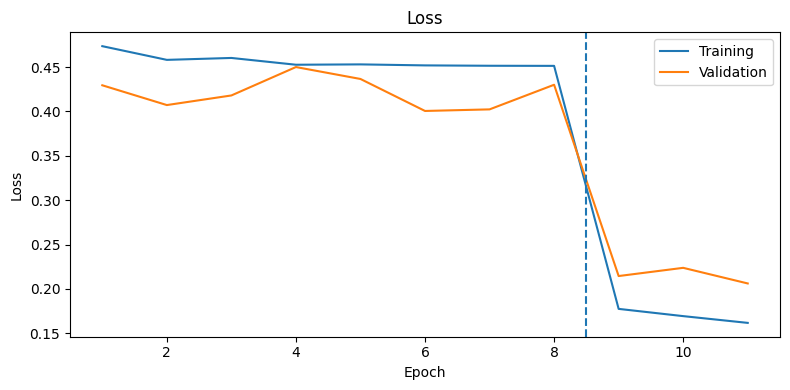

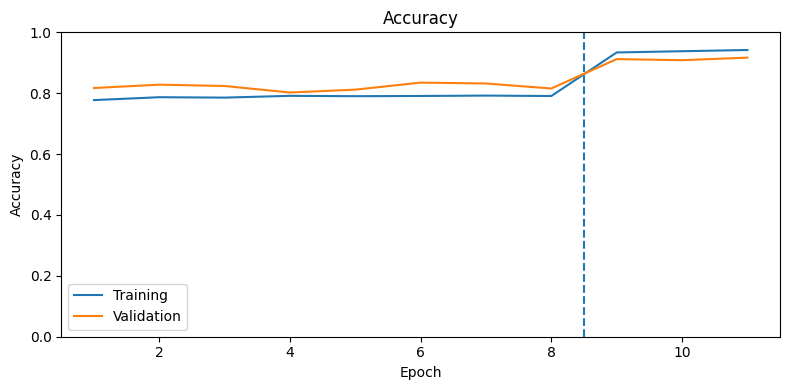

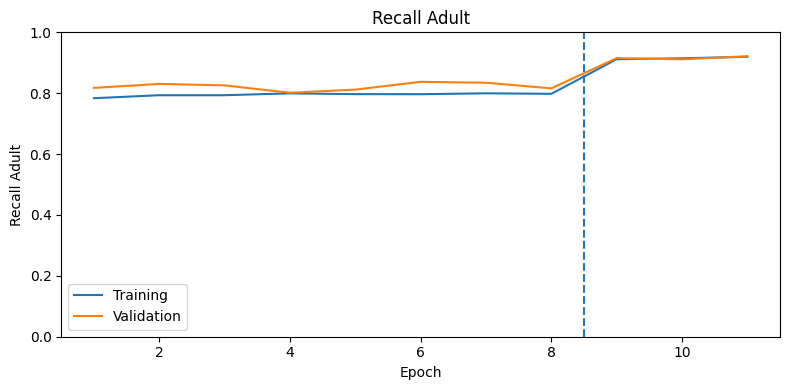

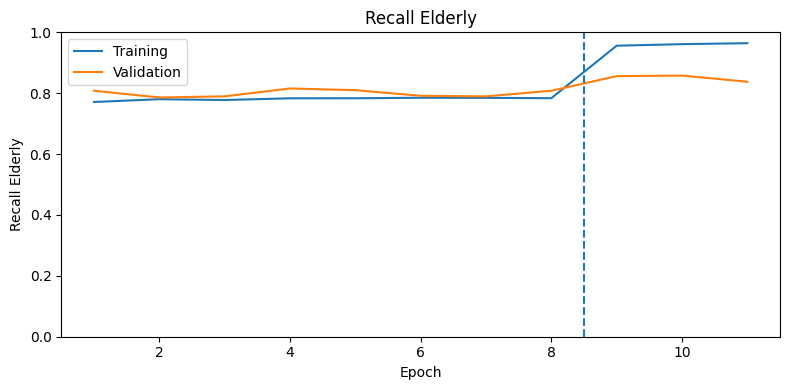

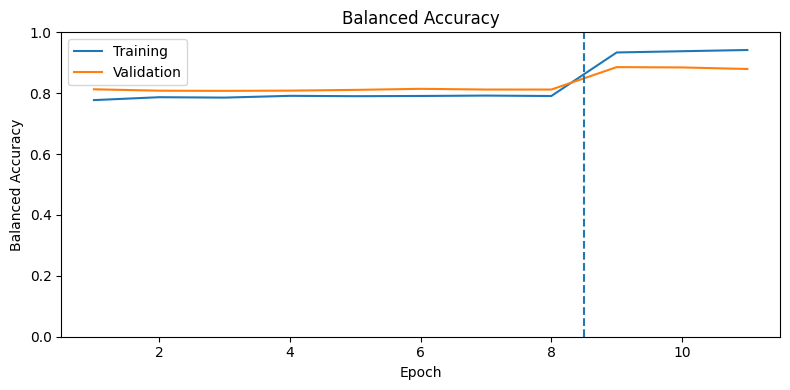

In [24]:
# cell:curves
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
history = pd.concat([pd.read_csv(OUTPUT_DIR / "head_training.csv"),
                     pd.read_csv(OUTPUT_DIR / "fine_training.csv")], ignore_index=True)
history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
for metric in ("loss", "accuracy", "recall_adult", "recall_elderly", "balanced_accuracy"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(1, len(history)+1), history[metric], label="Training")
    ax.plot(np.arange(1, len(history)+1), history["val_"+metric], label="Validation")
    ax.axvline(len(head_history.history["loss"])+0.5, linestyle="--")
    title = metric.replace("_", " ").title()
    ax.set(xlabel="Epoch", ylabel=title, title=title)
    if metric != "loss":
        ax.set_ylim(0, 1)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"training_{metric}.png", dpi=150)
    plt.show()
    plt.close(fig)

## 23. Evaluate on the existing holdout

In this cell we report accuracy, balanced accuracy and macro F1 on the same holdout split as before. Earlier results influenced this revision, so this is a comparison, not a completely unseen test. Final phone evaluation still needs new images.

In [25]:
# cell:evaluate
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
probabilities = model.predict(test_ds, verbose=0)
if not np.isfinite(probabilities).all():
    raise ValueError("The model produced invalid scores.")
y_true = test_df["label"].to_numpy()
y_pred = probabilities.argmax(axis=1)
majority_class = int(train_df["label"].value_counts().idxmax())
baseline_pred = np.full(len(y_true), majority_class)

def score_summary(truth, prediction):
    return {"accuracy": float(accuracy_score(truth, prediction)),
            "balanced_accuracy": float(balanced_accuracy_score(truth, prediction)),
            "macro_f1": float(f1_score(truth, prediction, average="macro",
                                       labels=list(range(N_CLASSES)), zero_division=0))}

model_scores = score_summary(y_true, y_pred)
results = pd.DataFrame([{"model": "Majority-class baseline", **score_summary(y_true, baseline_pred)},
                        {"model": TASK + " model", **model_scores}])
display(results)
results.to_csv(OUTPUT_DIR / "holdout_results.csv", index=False)
predictions = test_df.copy()
predictions["true_class"] = [CLASS_NAMES[value] for value in y_true]
predictions["predicted_class"] = [CLASS_NAMES[value] for value in y_pred]
predictions["model_score"] = probabilities.max(axis=1)
predictions["correct"] = y_true == y_pred
predictions.to_csv(OUTPUT_DIR / "holdout_predictions.csv", index=False)

,model,accuracy,balanced_accuracy,macro_f1
0,Majority-class baseline,0.946561,0.5000,0.486274
1,age model,0.911869,0.8664,0.724462


## 24. Check Adult and Elderly separately

In this cell we show precision, recall and F1 for both classes. The confusion matrix shows the real class in each row and the model prediction in each column.

,precision,recall,f1-score,support
Adult,0.988772,0.917310,0.951701,7776.000000
Elderly,0.357642,0.815490,0.497222,439.000000
accuracy,0.911869,0.911869,0.911869,0.911869
macro avg,0.673207,0.866400,0.724462,8215.000000
weighted avg,0.955045,0.911869,0.927414,8215.000000


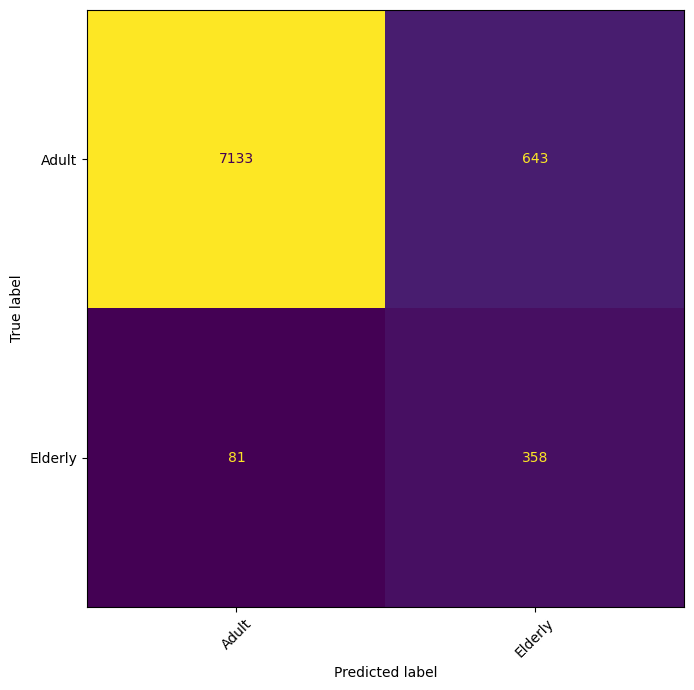

In [26]:
# cell:class_report
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
report = pd.DataFrame(classification_report(y_true, y_pred, labels=list(range(N_CLASSES)),
                      target_names=CLASS_NAMES, output_dict=True, zero_division=0)).T
display(report)
report.to_csv(OUTPUT_DIR / "classification_report.csv")
cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(OUTPUT_DIR / "confusion_matrix.csv")
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False,
                                                          xticks_rotation=45)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 25. Check performance inside the original age ranges

In this cell we check the Adult/Elderly prediction accuracy inside each original FairFace age range. This helps us see whether the model struggles more near the 60-year boundary or with the oldest faces.

In [27]:
# cell:task_check
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

age_range_rows = []

for age_range in ["20-29", "30-39", "40-49", "50-59", "60-69", "more than 70"]:
    mask = test_df["age"].eq(age_range).to_numpy()

    if not mask.any():
        continue

    age_range_rows.append({
        "fairface_age_range": age_range,
        "project_class": CLASS_NAMES[int(y_true[mask][0])],
        "images": int(mask.sum()),
        "accuracy": float(accuracy_score(y_true[mask], y_pred[mask])),
    })

age_range_results = pd.DataFrame(age_range_rows)

display(age_range_results)
age_range_results.to_csv(
    OUTPUT_DIR / "accuracy_by_original_age_range.csv",
    index=False,
)

# Also save the final two-class confusion counts in a simple table.
group_summary = pd.DataFrame({
    "class": CLASS_NAMES,
    "holdout_images": [
        int((y_true == class_id).sum())
        for class_id in range(N_CLASSES)
    ],
    "correct_predictions": [
        int(((y_true == class_id) & (y_pred == class_id)).sum())
        for class_id in range(N_CLASSES)
    ],
    "class_recall": [
        float((y_pred[y_true == class_id] == class_id).mean())
        for class_id in range(N_CLASSES)
    ],
})

display(group_summary)
group_summary.to_csv(
    OUTPUT_DIR / "adult_elderly_class_accuracy.csv",
    index=False,
)

,fairface_age_range,project_class,images,accuracy
0,20-29,Adult,3299,0.989088
1,30-39,Adult,2329,0.969515
2,40-49,Adult,1352,0.855030
3,50-59,Adult,796,0.572864
4,60-69,Elderly,321,0.775701
5,more than 70,Elderly,118,0.923729


,class,holdout_images,correct_predictions,class_recall
0,Adult,7776,7133,0.91731
1,Elderly,439,358,0.81549


## 26. Look at the mistakes

In this cell we look at some Adult and Elderly faces that the model classified incorrectly. This helps us understand the types of errors the model makes.

,true_class,predicted_class,model_score
72322,Adult,Elderly,0.999812
70142,Elderly,Adult,0.999554
73182,Adult,Elderly,0.997855
69092,Adult,Elderly,0.997675
69429,Adult,Elderly,0.997500
69577,Adult,Elderly,0.997313
68524,Adult,Elderly,0.997291
70835,Adult,Elderly,0.997262
69297,Elderly,Adult,0.996782
71556,Elderly,Adult,0.996166


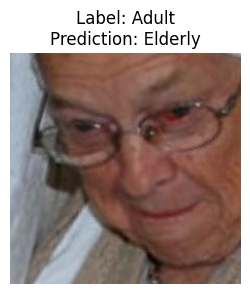

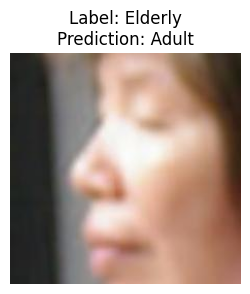

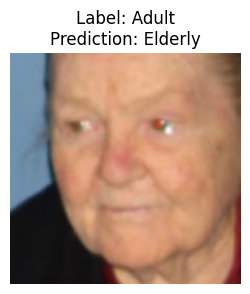

In [28]:
# cell:errors
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
mistakes = predictions.loc[~predictions["correct"]].sort_values("model_score", ascending=False)
display(mistakes[["true_class", "predicted_class", "model_score"]].head(10))
mistakes.to_csv(OUTPUT_DIR / "mistakes.csv", index=False)
if SHOW_FACE_IMAGES:
    for _, row in mistakes.head(3).iterrows():
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.imshow(open_face(row["path"], row[BOX_COLUMNS]))
        ax.set_title(f"Label: {row['true_class']}\nPrediction: {row['predicted_class']}")
        ax.axis("off")
        plt.show()

## 27. Export a full-precision Android model

In this cell we copy the chosen weights into a CPU model for export. Training still runs on the GPU. The CPU copy gives a like-for-like reference for the CPU TensorFlow Lite check. The saved classifier does not include the camera, face detector or app.

In [29]:
# cell:fp32
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Training uses mixed precision on the GPU.
# For deployment checking we rebuild the same architecture in float32 on CPU.
training_policy = tf.keras.mixed_precision.global_policy()

tf.keras.mixed_precision.set_global_policy(
    "float32"
)

try:
    with tf.device("/CPU:0"):
        cpu_reference, _ = build_age_model(
            weights=None
        )

        cpu_reference.set_weights(
            model.get_weights()
        )

        cpu_reference.trainable = False

        cpu_reference(
            tf.zeros(
                (
                    1,
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                    3,
                ),
                dtype=tf.float32,
            ),
            training=False,
        )

        converter = tf.lite.TFLiteConverter.from_keras_model(
            cpu_reference
        )

        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS
        ]

        fp32_bytes = converter.convert()

finally:
    tf.keras.mixed_precision.set_global_policy(
        training_policy
    )


FP32_PATH = (
    OUTPUT_DIR
    / f"{TASK}_fp32.tflite"
)

FP32_PATH.write_bytes(
    fp32_bytes
)

print("Saved:", FP32_PATH)

print(
    "Size in MB:",
    round(
        FP32_PATH.stat().st_size
        / 1e6,
        2,
    ),
)

Saved artifact at '/tmp/tmp1j78bx11'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='face_rgb')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  132488273358352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467746640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467748560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467748368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467748752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467746832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488262471696: T

## 28. Try a smaller Android model

In this cell we try INT8 conversion. It uses smaller numbers and may change accuracy. Only training images set the number ranges. If conversion fails, we keep the normal model and record the error.


In [30]:
# cell:int8
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
calibration_df = pd.concat([group.sample(min(200, len(group)), random_state=SEED)
                           for _, group in train_df.groupby("label")])
calibration_df.to_csv(OUTPUT_DIR / "calibration_images.csv", index=False)
assert set(calibration_df["path"]).issubset(set(train_df["path"]))

def representative_images():
    for images, _ in make_dataset(calibration_df):
        for image in images.numpy():
            yield [image[None].astype(np.float32)]

INT8_PATH = None
try:
    with tf.device("/CPU:0"):
        converter = tf.lite.TFLiteConverter.from_keras_model(cpu_reference)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_images
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        converted = converter.convert()
    path = OUTPUT_DIR / f"{TASK}_int8.tflite"
    path.write_bytes(converted)
    INT8_PATH = path
    print("Saved:", INT8_PATH)
except Exception as error:
    print("INT8 conversion failed. The FP32 model is still available.")
    print(type(error).__name__+": "+str(error))
    (OUTPUT_DIR / "int8_error.txt").write_text(str(error), encoding="utf-8")

Saved artifact at '/tmp/tmpqai3sz1i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='face_rgb')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  132488273358352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467747024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467746640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467748560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467748368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467748752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488467746832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132488262471696: T

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: /content/project_edge_ai/results/age/20260915_044643/age_int8.tflite


## 29. Check the converted models

In this cell we compare the CPU reference and the converted models on the same validation face crops. We check score differences, matching predictions and recall for both classes. A small score difference alone is not a failure. Large differences or worse class recall stop a model from being selected. The limits are project safety checks, not a guarantee of phone performance.

In [31]:
# cell:mobile_check
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def balanced_check_sample(frame, per_class, seed):
    return pd.concat([g.sample(min(per_class, len(g)), random_state=seed)
                      for _, g in frame.groupby("label")]).reset_index(drop=True)


def probability_check(values, rows, tolerance=1e-4):
    values = np.asarray(values, dtype=np.float32)
    if values.shape != (rows, 2) or not np.isfinite(values).all():
        raise ValueError("Wrong prediction shape or non-finite model scores.")
    if (values < -tolerance).any() or (values > 1+tolerance).any():
        raise ValueError("Model scores are outside the probability range.")
    if not np.allclose(values.sum(axis=1), 1, rtol=0, atol=tolerance):
        raise ValueError("Class probabilities do not sum to one. Check output scaling.")
    return values


def class_recalls(truth, prediction):
    truth, prediction = np.asarray(truth), np.asarray(prediction)
    if set(np.unique(truth)) != {0, 1}:
        raise ValueError("The check sample must contain both age classes.")
    return np.array([np.mean(prediction[truth == i] == i) for i in (0, 1)])


def conversion_report(truth, reference, candidate, limits, quantized=False):
    truth = np.asarray(truth)
    reference = probability_check(reference, len(truth))
    candidate = probability_check(candidate, len(truth), tolerance=0.02 if quantized else 1e-4)
    difference = np.abs(reference-candidate)
    ref_labels, labels = reference.argmax(axis=1), candidate.argmax(axis=1)
    ref_recall, recall = class_recalls(truth, ref_labels), class_recalls(truth, labels)
    result = {
        "max_abs_difference": float(difference.max()),
        "mean_abs_difference": float(difference.mean()),
        "p99_abs_difference": float(np.quantile(difference, 0.99)),
        "prediction_agreement": float(np.mean(ref_labels == labels)),
        "accuracy": float(np.mean(truth == labels)),
        "recall_adult": float(recall[0]), "recall_elderly": float(recall[1]),
        "balanced_accuracy": float(recall.mean()),
        "balanced_accuracy_drop": float(ref_recall.mean()-recall.mean()),
        "largest_class_recall_drop": float(np.max(ref_recall-recall)),
    }
    reasons = []
    for key, limit_key in [("max_abs_difference", "max_abs"), ("mean_abs_difference", "mean_abs"),
        ("balanced_accuracy_drop", "max_balanced_accuracy_drop"),
        ("largest_class_recall_drop", "max_class_recall_drop")]:
        if result[key] > limits[limit_key]+1e-12:
            reasons.append(key+" exceeds the set limit")
    if result["prediction_agreement"]+1e-12 < limits["min_agreement"]:
        reasons.append("prediction agreement is below the set limit")
    result["passed"] = not reasons
    result["reason"] = "; ".join(reasons) or "All checks passed"
    return result


def encode_input(value, detail):
    value = np.asarray(value, dtype=np.float32)
    if not np.isfinite(value).all():
        raise ValueError("Input contains invalid pixels.")
    if np.issubdtype(detail["dtype"], np.integer):
        scale, zero = detail["quantization"]
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError("Invalid input quantization scale.")
        bounds = np.iinfo(detail["dtype"])
        value = np.clip(np.rint(value/scale+zero), bounds.min, bounds.max)
    return value.astype(detail["dtype"])


def decode_output(value, detail):
    value = np.asarray(value)
    if np.issubdtype(detail["dtype"], np.integer):
        scale, zero = detail["quantization"]
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError("Invalid output quantization scale.")
        value = (value.astype(np.float32)-zero)*scale
    return value.astype(np.float32)


def open_lite(path):
    interpreter = tf.lite.Interpreter(model_path=str(path), num_threads=4)
    interpreter.allocate_tensors()
    inputs, outputs = interpreter.get_input_details(), interpreter.get_output_details()
    if len(inputs) != 1 or len(outputs) != 1:
        raise ValueError("Expected one image input and one two-class output.")
    if list(inputs[0]["shape"]) != [1, IMAGE_SIZE, IMAGE_SIZE, 3] or list(outputs[0]["shape"]) != [1, 2]:
        raise ValueError("Unexpected TensorFlow Lite input/output shape.")
    return interpreter, inputs[0], outputs[0]


def lite_predictions(path, frame):
    interpreter, input_info, output_info = open_lite(path)
    values = []
    for images, _ in make_dataset(frame):
        for image in images.numpy():
            interpreter.set_tensor(input_info["index"], encode_input(image[None], input_info))
            interpreter.invoke()
            values.append(decode_output(interpreter.get_tensor(output_info["index"])[0], output_info))
    return np.asarray(values, dtype=np.float32)


def cpu_predictions(frame):
    values = []
    for images, _ in make_dataset(frame):
        with tf.device("/CPU:0"):
            values.append(cpu_reference(images, training=False).numpy())
    return np.concatenate(values)


validation_sample = balanced_check_sample(val_df, MOBILE_IMAGES_PER_CLASS, SEED)
validation_sample.to_csv(OUTPUT_DIR / "conversion_validation_images.csv", index=False)
truth = validation_sample["label"].to_numpy()
keras_scores = cpu_predictions(validation_sample)
fp32_scores = lite_predictions(FP32_PATH, validation_sample)
fp32_report = conversion_report(truth, keras_scores, fp32_scores, FP32_LIMITS)
# This GPU/CPU comparison is diagnostic. It is not the conversion test reference.
gpu_scores = model.predict(make_dataset(validation_sample), verbose=0)
print("Largest GPU-Keras / CPU-Keras difference:", float(np.max(np.abs(gpu_scores-keras_scores))))
print("Largest CPU-Keras / FP32-Lite difference:", fp32_report["max_abs_difference"])
print("FP32 class-prediction agreement:", f"{fp32_report['prediction_agreement']:.2%}")
if fp32_report["max_abs_difference"] > 0.001 and fp32_report["passed"]:
    print("Small numerical drift recorded. Agreement and both recall checks passed.")

format_rows = [dict(format="FP32", size_MB=FP32_PATH.stat().st_size/1e6, **fp32_report)]
mobile_models = {"FP32": FP32_PATH}
CHOSEN_FORMAT = "FP32"
if INT8_PATH is not None:
    try:
        int8_scores = lite_predictions(INT8_PATH, validation_sample)
        int8_report = conversion_report(truth, fp32_scores, int8_scores, INT8_LIMITS, quantized=True)
        format_rows.append(dict(format="INT8", size_MB=INT8_PATH.stat().st_size/1e6, **int8_report))
        if fp32_report["passed"] and int8_report["passed"]:
            mobile_models["INT8"] = INT8_PATH
            if INT8_PATH.stat().st_size < FP32_PATH.stat().st_size:
                CHOSEN_FORMAT = "INT8"
        else:
            print("INT8 is not selected:", int8_report["reason"])
    except Exception as error:
        print("INT8 checking failed; keeping FP32 as the candidate:", error)
        (OUTPUT_DIR / "int8_validation_error.txt").write_text(str(error), encoding="utf-8")

format_table = pd.DataFrame(format_rows).set_index("format")
display(format_table)
format_table.to_csv(OUTPUT_DIR / "format_validation.csv")
(OUTPUT_DIR / "conversion_limits.json").write_text(json.dumps({
    "FP32": FP32_LIMITS, "INT8": INT8_LIMITS,
    "sample_images_per_class": MOBILE_IMAGES_PER_CLASS,
    "fp32_reference": "Separate float32 Keras model on CPU, identical saved weights and preprocessing",
}, indent=2), encoding="utf-8")
diagnostic = validation_sample[["path", "label"]].copy()
for i, name in enumerate(CLASS_NAMES):
    diagnostic["keras_cpu_"+name] = keras_scores[:, i]
    diagnostic["fp32_"+name] = fp32_scores[:, i]
diagnostic.to_csv(OUTPUT_DIR / "fp32_check_predictions.csv", index=False)
if not fp32_report["passed"]:
    raise RuntimeError("FP32 conversion failed the checks. See format_validation.csv: "+fp32_report["reason"])
print("Candidate Android format:", CHOSEN_FORMAT)

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Largest GPU-Keras / CPU-Keras difference: 0.04976159334182739
Largest CPU-Keras / FP32-Lite difference: 1.4841556549072266e-05
FP32 class-prediction agreement: 100.00%


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 checking failed; keeping FP32 as the candidate: failed to create XNNPACK runtimeNode number 117 (TfLiteXNNPackDelegate) failed to prepare.


,size_MB,max_abs_difference,mean_abs_difference,p99_abs_difference,prediction_agreement,accuracy,...,recall_elderly,balanced_accuracy,balanced_accuracy_drop,largest_class_recall_drop,passed,reason
format,,,,,,,,,,,,,
FP32,3.735872,0.000015,0.000001,0.000008,1.0,0.886719,...,0.875,0.886719,0.0,0.0,True,All checks passed


Candidate Android format: FP32


## 30. Compare models on the same holdout sample

In this cell we compare both classes using the same fixed sample for each model format. This sample has up to 256 images per class; it is not the full holdout. Recall and balanced accuracy show performance for both groups. The timing is on this computer's CPU, not an Android phone.

In [32]:
# cell:comparison
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def computer_latency(path, sample):
    interpreter, details, _ = open_lite(path)
    interpreter.set_tensor(details["index"], encode_input(sample[None], details))
    for _ in range(10):
        interpreter.invoke()
    times = []
    for _ in range(50):
        started = time.perf_counter()
        interpreter.invoke()
        times.append((time.perf_counter()-started)*1000)
    return float(np.median(times)), float(np.percentile(times, 95))

comparison_df = balanced_check_sample(test_df, MOBILE_IMAGES_PER_CLASS, SEED)
comparison_df.to_csv(OUTPUT_DIR / "mobile_comparison_images.csv", index=False)
comparison_labels = comparison_df["label"].to_numpy()
keras_comparison = cpu_predictions(comparison_df)

def comparison_row(name, values, size, median=np.nan, p95=np.nan):
    predicted = values.argmax(axis=1)
    recall = class_recalls(comparison_labels, predicted)
    return {"format": name, "images": len(comparison_df),
        "accuracy": float(accuracy_score(comparison_labels, predicted)),
        "balanced_accuracy": float(recall.mean()), "recall_adult": float(recall[0]),
        "recall_elderly": float(recall[1]),
        "macro_f1": float(f1_score(comparison_labels, predicted, average="macro", zero_division=0)),
        "size_MB": size, "computer_CPU_median_ms": median, "computer_CPU_p95_ms": p95}

comparison_rows = [comparison_row("Keras CPU reference", keras_comparison,
                                 (OUTPUT_DIR/"best_model.h5").stat().st_size/1e6)]
example, _ = next(iter(make_dataset(validation_sample.head(1))))
for name, path in mobile_models.items():
    values = lite_predictions(path, comparison_df)
    median_ms, p95_ms = computer_latency(path, example[0].numpy())
    comparison_rows.append(comparison_row(name, values, path.stat().st_size/1e6, median_ms, p95_ms))
comparison = pd.DataFrame(comparison_rows)
display(comparison)
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
print("CPU timing: 4 threads, 10 warm-up calls, 50 measured calls. Image loading is excluded.")
print("These are NOT phone timings. Holdout results did not choose the exported format.")

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,format,images,accuracy,balanced_accuracy,recall_adult,recall_elderly,macro_f1,size_MB,computer_CPU_median_ms,computer_CPU_p95_ms
0,Keras CPU reference,512,0.871094,0.871094,0.921875,0.820312,0.87076,4.077616,NaN,NaN
1,FP32,512,0.871094,0.871094,0.921875,0.820312,0.87076,3.735872,13.013474,16.539484


CPU timing: 4 threads, 10 warm-up calls, 50 measured calls. Image loading is excluded.
These are NOT phone timings. Holdout results did not choose the exported format.


## 31. Save the Android model and its input rules

In this cell we save the chosen Adult/Elderly model, the label order and the input rules. Android must use the same RGB face crop and image size.

In [33]:
# cell:save
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHOSEN_PATH = OUTPUT_DIR / f"{TASK}_android.tflite"
shutil.copyfile(mobile_models[CHOSEN_FORMAT], CHOSEN_PATH)
(OUTPUT_DIR / "labels.txt").write_text("\n".join(CLASS_NAMES) + "\n", encoding="utf-8")
interpreter = tf.lite.Interpreter(model_path=str(CHOSEN_PATH))
interpreter.allocate_tensors()

def tensor_rules(details):
    return {"shape": details["shape"].tolist(), "dtype": np.dtype(details["dtype"]).name,
            "scale": float(details["quantization"][0]), "zero_point": int(details["quantization"][1])}

settings = {
    "course": "DLBAIPEAI", "task": "Task 2", "model_task": TASK,
    "architecture": "MobileNetV3Small",
    "age_definition": {"Adult": "20-59", "Elderly": "60+"},
    "excluded_age_ranges": ["0-2", "3-9", "10-19"],
    "seed": SEED, "class_names": CLASS_NAMES,
    "notebook_revision": NOTEBOOK_REVISION,
    "training_sampling": "exact half Adult / half Elderly; shuffled cycles; training augmentation only",
    "training_class_weights": None, "samples_per_epoch": STEPS_PER_EPOCH*BATCH_SIZE,
    "checkpoint_rule": "highest validation balanced accuracy; validation loss breaks stage ties",
    "decision_rule": "argmax of Adult/Elderly scores; no holdout-tuned threshold",
    "probability_note": "Balanced training changes the class prior; scores are not calibrated real-world age probabilities.",
    "reused_holdout_informed_revision": True,
    "conversion_fp32_limits": FP32_LIMITS, "conversion_int8_limits": INT8_LIMITS,
    "dataset_handle": KAGGLE_HANDLE, "dataset_directory": str(DATA_DIR),
    "input": tensor_rules(interpreter.get_input_details()[0]),
    "output": tensor_rules(interpreter.get_output_details()[0]),
    "image_rule": "Crop face, convert to RGB, resize to 224x224 using bilinear interpolation.",
    "pixel_rule": "Float pixels 0-255. Scaling is already inside the model. Do not divide by 255.",
    "integer_rule": "For integer tensors use the saved scale and zero point, with rounding and clipping.",
    "includes_face_detector": False, "measured_on_phone": False,
    "split_sizes": {name: len(frame) for name, frame in frames.items()},
    "chosen_stage": BEST_STAGE, "chosen_format": CHOSEN_FORMAT,
    "training_seconds": head_seconds + fine_seconds,
    "gpu_name": GPU_NAME, "gpu_forward_backward_test_passed": GPU_READY,
    "holdout_scores": model_scores,
    "versions": {
        "tensorflow": tf.__version__,
        **{name: metadata.version(name) for name in packages},
    },
    "system": platform.platform(), "tensorflow_devices": [str(device) for device in gpus],
}
(OUTPUT_DIR / "model_settings.json").write_text(json.dumps(settings, indent=2), encoding="utf-8")
print("Android model:", CHOSEN_PATH)
print("The training input starts with a cropped face. The app must do this crop too.")

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Android model: /content/project_edge_ai/results/age/20260915_044643/age_android.tflite
The training input starts with a cropped face. The app must do this crop too.


## 32. Summarise this run

In this cell we summarise the measured Adult/Elderly results. The notebook does not create results before training. The Android app and the required 20-image device experiment still need to be completed.

In [34]:
# cell:summary
display(Markdown(
    f"### Measured results\n\n"
    f"The age model was trained as a **two-class Adult/Elderly classifier**. "
    f"Adult was defined as **20-59 years** and Elderly as **60+ years**. "
    f"Images below age 20 were excluded.\n\n"
    f"The training set contained **{len(train_df):,} different image files**. "
    f"Each epoch used **{STEPS_PER_EPOCH*BATCH_SIZE:,} image presentations**, half from each class. "
    f"Repeats are not counted as new people. "
    f"The validation set had **{len(val_df):,} images**. "
    f"The final holdout had **{len(test_df):,} images**.\n\n"
    f"Holdout accuracy was **{model_scores['accuracy']:.2%}**. "
    f"Balanced accuracy was **{model_scores['balanced_accuracy']:.2%}**. "
    f"Macro F1 was **{model_scores['macro_f1']:.3f}**. "
    f"The selected checkpoint was **{BEST_STAGE}**, and the candidate phone format was **{CHOSEN_FORMAT}**.\n\n"
    f"The original FairFace age-range table above should also be reviewed because "
    f"it shows where the two-class model makes most of its mistakes. "
    f"This holdout was already inspected during development, so the new phone test remains important. "
    f"Balanced training may improve Elderly recall but can reduce Adult recall or overall accuracy. "
    f"Only the measured results can show the trade-off."
))

### Measured results

The age model was trained as a **two-class Adult/Elderly classifier**. Adult was defined as **20-59 years** and Elderly as **60+ years**. Images below age 20 were excluded.

The training set contained **55,533 different image files**. Each epoch used **104,928 image presentations**, half from each class. Repeats are not counted as new people. The validation set had **9,801 images**. The final holdout had **8,215 images**.

Holdout accuracy was **91.19%**. Balanced accuracy was **86.64%**. Macro F1 was **0.724**. The selected checkpoint was **fine**, and the candidate phone format was **FP32**.

The original FairFace age-range table above should also be reviewed because it shows where the two-class model makes most of its mistakes. This holdout was already inspected during development, so the new phone test remains important. Balanced training may improve Elderly recall but can reduce Adult recall or overall accuracy. Only the measured results can show the trade-off.

### What remains for Task 2

The final phone app must recognise age group, gender and expression on the device. For this age model, the app will return **Adult** or **Elderly**.

The final experiment must still use the 20 device-captured images required by the task brief. Those images must not be used for training or model selection. Real phone measurements and the final test results must be included in the report.

The source code, critical review of the results and AI-use statement still belong in the course submission.

### Sources

IU International University. (n.d.). DLBAIPEAI - Project Edge AI: Task - Project report (Task 2, pp. 3-4). Course document supplied with this project.

Karkkainen, K., & Joo, J. (2021). FairFace: Face attribute dataset for balanced race, gender, and age for bias measurement and mitigation. Proceedings of the IEEE/CVF Winter Conference on Applications of Computer Vision, 1548-1558. [Paper and official project](https://github.com/joojs/fairface).

Kaggle. (n.d.). *FAIRFACE DATASET*. Kaggle mirror used for the notebook download. https://www.kaggle.com/datasets/mehmoodsheikh/fairface-dataset

Howard, A., Sandler, M., Chu, G., Chen, L.-C., Chen, B., Tan, M., Wang, W., Zhu, Y., Pang, R., Vasudevan, V., Le, Q. V., & Adam, H. (2019). Searching for MobileNetV3. arXiv. [Paper](https://arxiv.org/abs/1905.02244).

TensorFlow. (n.d.-a). Install TensorFlow with pip. [Documentation](https://www.tensorflow.org/install/pip).

TensorFlow. (n.d.-b). tf.keras.applications.MobileNetV3Small. [Model and input rules](https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV3Small).

TensorFlow. (n.d.-c). Post-training integer quantization. [Conversion guide](https://www.tensorflow.org/lite/performance/post_training_integer_quant).

All result tables and graphs in this notebook are produced from the loaded data when the cells run. Face examples remain subject to their dataset terms.


TensorFlow. (n.d.-d). Build from source on Windows: Tested GPU configurations. [Compatibility table](https://www.tensorflow.org/install/source_windows#gpu).

NVIDIA. (n.d.). Ada compatibility guide. [CUDA compatibility](https://docs.nvidia.com/cuda/ada-compatibility-guide/index.html).

**Project age definition:** FairFace provides age ranges rather than an Adult/Elderly label. For this project, the clearly separated FairFace ranges 20-59 are mapped to Adult and 60+ to Elderly. This boundary is a project definition and is stated explicitly in the report.

TensorFlow. (n.d.). *Classification on imbalanced data*. https://www.tensorflow.org/tutorials/structured_data/imbalanced_data

TensorFlow. (n.d.). *tf.config.experimental.enable_tensor_float_32_execution*. https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_tensor_float_32_execution

Kaggle. (n.d.). *kagglehub v0.3.13: configuration and dataset download source code*. https://github.com/Kaggle/kagglehub/tree/v0.3.13/src/kagglehub

**Export check note:** Small differences can occur between inference backends. The notebook records the differences and uses the stated validation-based agreement and recall limits. The screenshot alone did not establish the exact cause of the earlier failure.


## 33. Make the notebook PDF

In this cell we automatically create a PDF of the saved notes, code and recorded outputs. Save any changes to the notes first. Training is not run again. No LaTeX, browser installer or helper file is needed.


In [35]:
# cell:pdf
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

import base64
import textwrap
import copy
import re
import io

from html import escape

import nbformat

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import (
    getSampleStyleSheet,
    ParagraphStyle,
)
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Preformatted,
    Spacer,
    Image as PDFImage,
)


# Get the current notebook directly from Google Colab.
try:
    from google.colab import _message

    response = _message.blocking_request(
        "get_ipynb",
        timeout_sec=30,
    )

    notebook_data = response.get(
        "ipynb"
    )

    if notebook_data is None:
        raise RuntimeError(
            "Colab did not return the current notebook."
        )

    notebook = nbformat.from_dict(
        notebook_data
    )

except Exception as error:
    raise RuntimeError(
        "Could not read the current Colab notebook."
    ) from error


# Colab can return cell source as either a string
# or a list of strings. Make every source one string.
for cell in notebook.cells:

    source = cell.get(
        "source",
        "",
    )

    if isinstance(
        source,
        list,
    ):
        source = "".join(
            source
        )

    elif not isinstance(
        source,
        str,
    ):
        source = str(
            source
        )

    cell["source"] = source

    if cell.cell_type == "code":

        key = (
            source.splitlines()[0].strip()
            if source
            else ""
        )

        cell.outputs = []
        cell.execution_count = None

        if key in pdf_recorder.records:

            record = copy.deepcopy(
                pdf_recorder.records[key]
            )

            cell.outputs = nbformat.from_dict(
                {
                    "outputs": record.get(
                        "outputs",
                        [],
                    )
                }
            ).outputs

            cell.execution_count = record.get(
                "execution_count"
            )


# PDF styles.
styles = getSampleStyleSheet()

styles.add(
    ParagraphStyle(
        "Notes",
        fontName="Helvetica",
        fontSize=10,
        leading=14,
        spaceAfter=8,
    )
)

styles.add(
    ParagraphStyle(
        "NotebookCode",
        fontName="Courier",
        fontSize=8,
        leading=10.5,
        spaceAfter=7,
    )
)

styles["Heading1"].fontSize = 18
styles["Heading1"].leading = 22

styles["Heading2"].fontSize = 12
styles["Heading2"].leading = 16

story = []


def plain(value):

    if isinstance(
        value,
        list,
    ):
        text = "".join(
            value
        )

    else:
        text = str(
            value
        )

    # Remove terminal colour codes.
    text = re.sub(
        r"\x1b\[[0-?]*[ -/]*[@-~]",
        "",
        text,
    )

    replacements = {
        "–": "-",
        "—": "-",
        "→": "->",
        "’": "'",
        "“": '"',
        "”": '"',
    }

    for old, new in replacements.items():
        text = text.replace(
            old,
            new,
        )

    return (
        text
        .encode(
            "latin-1",
            errors="replace",
        )
        .decode(
            "latin-1"
        )
    )


def inline(text):

    text = escape(
        plain(text)
    )

    text = re.sub(
        r"\[([^\]]+)\]\((https?://[^\s)]+)\)",
        r'<link href="\2">\1</link>',
        text,
    )

    text = re.sub(
        r"\*\*(.+?)\*\*",
        r"<b>\1</b>",
        text,
    )

    text = re.sub(
        r"`([^`]+)`",
        r'<font name="Courier">\1</font>',
        text,
    )

    return text


def add_code(text):

    lines = []

    for line in plain(
        text
    ).splitlines():

        wrapped = textwrap.wrap(
            line.expandtabs(4),
            98,
            replace_whitespace=False,
            drop_whitespace=False,
            break_on_hyphens=False,
        )

        lines.extend(
            wrapped or [""]
        )

    for start in range(
        0,
        len(lines),
        22,
    ):

        story.append(
            Preformatted(
                "\n".join(
                    lines[
                        start:start + 22
                    ]
                ),
                styles["NotebookCode"],
            )
        )


def add_notes(text):

    for paragraph in plain(
        text
    ).split(
        "\n\n"
    ):

        paragraph = paragraph.strip()

        if not paragraph:
            continue

        heading = re.match(
            r"^(#{1,3})\s+(.*)$",
            paragraph,
            re.S,
        )

        if heading:

            style = styles[
                "Heading1"
                if len(
                    heading[1]
                ) == 1
                else "Heading2"
            ]

            story.append(
                Paragraph(
                    inline(
                        heading[2]
                    ),
                    style,
                )
            )

        else:

            story.append(
                Paragraph(
                    inline(
                        paragraph
                    ).replace(
                        "\n",
                        "<br/>",
                    ),
                    styles["Notes"],
                )
            )


# Add every notebook cell to the PDF.
for number, cell in enumerate(
    notebook.cells,
    1,
):

    if cell.cell_type == "markdown":

        add_notes(
            cell.source
        )

    elif cell.cell_type == "code":

        status = (
            "recorded"
            if cell.execution_count is not None
            else "output not recorded"
        )

        story.append(
            Paragraph(
                f"Code cell {number} - {status}",
                styles["Heading3"],
            )
        )

        add_code(
            cell.source
        )

        for output in cell.outputs:

            if output.get(
                "output_type"
            ) == "stream":

                add_code(
                    output.get(
                        "text",
                        "",
                    )
                )

            else:

                data = output.get(
                    "data",
                    {},
                )

                if "image/png" in data:

                    encoded = data[
                        "image/png"
                    ]

                    if isinstance(
                        encoded,
                        list,
                    ):
                        encoded = "".join(
                            encoded
                        )

                    image = PDFImage(
                        io.BytesIO(
                            base64.b64decode(
                                encoded
                            )
                        )
                    )

                    scale = min(
                        500 / image.imageWidth,
                        330 / image.imageHeight,
                        1.0,
                    )

                    image.drawWidth *= scale
                    image.drawHeight *= scale

                    story.append(
                        image
                    )

                    story.append(
                        Spacer(
                            1,
                            8,
                        )
                    )

                elif "text/markdown" in data:

                    add_notes(
                        data[
                            "text/markdown"
                        ]
                    )

                elif "text/plain" in data:

                    add_code(
                        data[
                            "text/plain"
                        ]
                    )


# Save the PDF.
PDF_PATH = (
    OUTPUT_DIR
    / (
        NOTEBOOK_NAME
        + ".pdf"
    )
)


def page_number(
    canvas,
    document,
):

    canvas.setFont(
        "Helvetica",
        8,
    )

    canvas.drawString(
        40,
        22,
        "DLBAIPEAI - Task 2 - "
        + TASK.title()
        + " model",
    )

    canvas.drawRightString(
        A4[0] - 40,
        22,
        f"Page {document.page}",
    )


SimpleDocTemplate(
    str(PDF_PATH),
    pagesize=A4,
    leftMargin=40,
    rightMargin=40,
    topMargin=38,
    bottomMargin=38,
    title=NOTEBOOK_NAME,
    author="W. Pretorius",
).build(
    story,
    onFirstPage=page_number,
    onLaterPages=page_number,
)


# Save an executed notebook copy too.
EXECUTED_PATH = (
    OUTPUT_DIR
    / (
        NOTEBOOK_NAME
        + "_executed.ipynb"
    )
)

nbformat.write(
    notebook,
    EXECUTED_PATH,
)

print(
    "Notebook PDF saved:",
    PDF_PATH,
)

print(
    "Executed notebook saved:",
    EXECUTED_PATH,
)

## Download the Colab results

In this cell we put the trained model, tables, graphs and PDF into one ZIP file and download it to the computer.


In [ ]:
# cell:colab_download
import shutil
from google.colab import files as colab_files

archive_base = PROJECT_DIR / f"age_results_{OUTPUT_DIR.name}"

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Created:", archive_path)
colab_files.download(archive_path)